In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import auc, roc_curve

# Data Loading

In [2]:
df = yf.download('XOM', start = "2023-01-01", end = "2026-01-01")

/tmp/ipykernel_422/2934287638.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('XOM', start = "2023-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
df2 = pd.DataFrame()
df2['close'] = df['Close']
df2['high'] = df['High']
df2['low'] = df['Low']
df2['open'] = df['Open']
df2['volume'] = df['Volume']

df2.head()


,close,high,low,open,volume
Date,,,,,
2023-01-03,94.790825,97.914619,93.883051,97.701027,15146200
2023-01-04,95.066696,95.369290,93.233358,93.268958,18058400
2023-01-05,97.193733,97.852310,94.612816,94.639514,15946600
2023-01-06,98.368484,99.667841,97.603109,97.968000,16348100
2023-01-09,96.535149,99.356355,95.947765,99.356355,17964600


# Tick-Test Rule + Quote Rule Algorithm

In [4]:
df2['price_diff'] = df2['close'].diff()

In [5]:
df2['midpoint'] = (df2['high'] + df2['low'])/2

In [6]:
def tick_test_algo(row):
  if row['price_diff'] > 0:
    return 1
  elif row['price_diff'] < 0:
    return 0
  else:
    return np.nan

def quote_rule_algo(row):
  if row['close'] > row['midpoint']:
    return 1
  elif row['close'] < row['midpoint']:
    return 0
  else:
    return tick_test_algo(row)

df2['target'] = df2.apply(quote_rule_algo, axis = 1)



In [7]:
df2['target'] = df2['target'].ffill()

In [8]:
df2 = df2.dropna()

# Feature Engineering

In [9]:
df2['open_close_diff'] = df2['open'] - df2['close']

In [10]:
df2['high_low_diff'] = df2['high'] - df2['low']

In [11]:
df2['volume_change'] = df2['volume'].pct_change()

In [12]:
df2 = df2.dropna()

# Split Data

In [13]:
X = df2[['open_close_diff', 'high_low_diff', 'volume_change']]
y = df2['target']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2,
                                                    shuffle = False)

# Model Training

In [17]:
# initialize the base random forest regressor
rfr = RandomForestClassifier(random_state = 42)

# define the hyperparameter grid
param_grid = {'n_estimators': [50, 60, 70, 80, 90, 100],
              'max_depth': [8, 9, 10],
              'min_samples_leaf': [1, 2, 3, 4, 5],
              'min_samples_split': [2, 3, 4, 5]}

# set up time series split
tscv = TimeSeriesSplit(n_splits = 5)

# set up the grid search cross-validation configuration
grid_search = GridSearchCV(estimator = rfr,
                           param_grid = param_grid,
                           cv = tscv,
                           n_jobs = 1,
                           verbose = 3,
                           scoring = 'accuracy',
                           return_train_score = True,
                           refit = True)

# execute the search over all parameter combination
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
[CV 1/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.990, test=0.810) total time=   0.2s
[CV 2/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=1.000, test=0.770) total time=   0.2s
[CV 3/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.987, test=0.780) total time=   0.2s
[CV 4/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.980, test=0.840) total time=   0.2s
[CV 5/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=50;, score=(train=0.968, test=0.760) total time=   0.2s
[CV 1/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=60;, score=(train=1.000, test=0.820) total time=   0.2s
[CV 2/5] END max_depth=8, min_samples_leaf=1, min_samples_split=2, n_estimators=60;, score=(train=1.000, test=0.770) tot

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestClassifier(random_state=42), n_jobs=1,
             param_grid={'max_depth': [8, 9, 10],
                         'min_samples_leaf': [1, 2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4, 5],
                         'n_estimators': [50, 60, 70, 80, 90, 100]},
             return_train_score=True, scoring='accuracy', verbose=3)

In [18]:
print(grid_search.best_params_)

{'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 70}


In [19]:
print(grid_search.best_score_)

0.8099999999999999


# Model Evaluation

In [20]:
y_pred_train = grid_search.predict(X_train)
print(classification_report(y_pred_train, y_train, target_names = ['Buy', 'Sell']))

              precision    recall  f1-score   support

         Buy       0.90      0.93      0.91       292
        Sell       0.93      0.90      0.91       308

    accuracy                           0.91       600
   macro avg       0.91      0.91      0.91       600
weighted avg       0.91      0.91      0.91       600



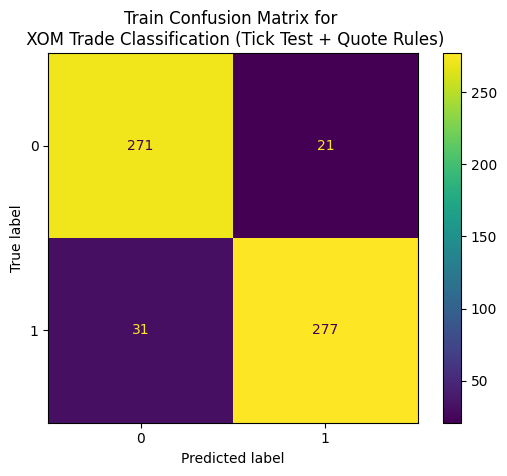

In [21]:
cm_train = confusion_matrix(y_pred_train, y_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix = cm_train)
disp_train.plot()
plt.title("Train Confusion Matrix for \n XOM Trade Classification (Tick Test + Quote Rules)")
plt.grid(False)
plt.show()

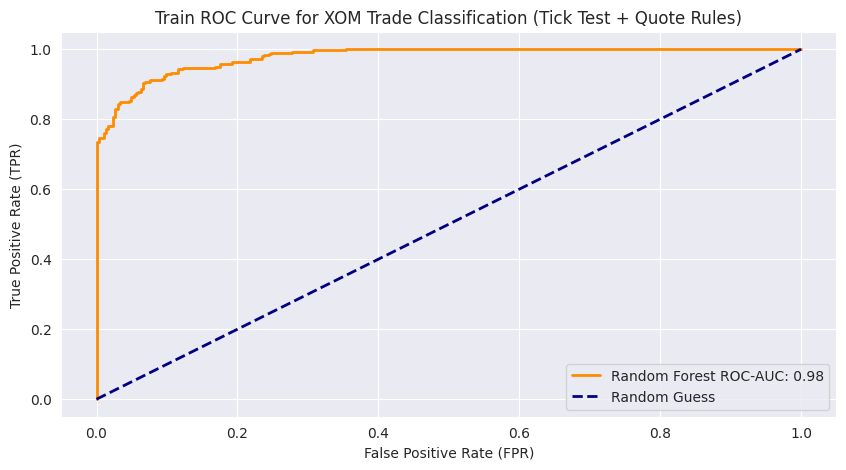

In [22]:
y_prob_train = grid_search.predict_proba(X_train)[:, 1]
fpr_train, tpr_train, thresholds = roc_curve(y_train, y_prob_train)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize = (10, 5))
sns.set_style("darkgrid")
plt.plot(fpr_train, tpr_train, color = "darkorange", lw = 2, label = "Random Forest ROC-AUC: {:.2f}".format(roc_auc_train))
plt.plot([0, 1], [0, 1], color = "navy", lw = 2, linestyle = "--", label = "Random Guess")
plt.title("Train ROC Curve for XOM Trade Classification (Tick Test + Quote Rules)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()

In [23]:
y_pred_test = grid_search.predict(X_test)
print(classification_report(y_pred_test, y_test, target_names = ['Buy', 'Sell']))

              precision    recall  f1-score   support

         Buy       0.78      0.85      0.81        61
        Sell       0.89      0.83      0.86        89

    accuracy                           0.84       150
   macro avg       0.83      0.84      0.84       150
weighted avg       0.84      0.84      0.84       150



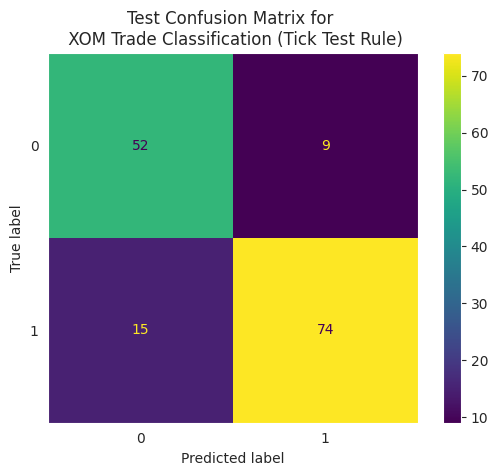

In [24]:
cm_test = confusion_matrix(y_pred_test, y_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix = cm_test)
disp_test.plot()
plt.title("Test Confusion Matrix for \n XOM Trade Classification (Tick Test Rule)")
plt.grid(False)
plt.show()

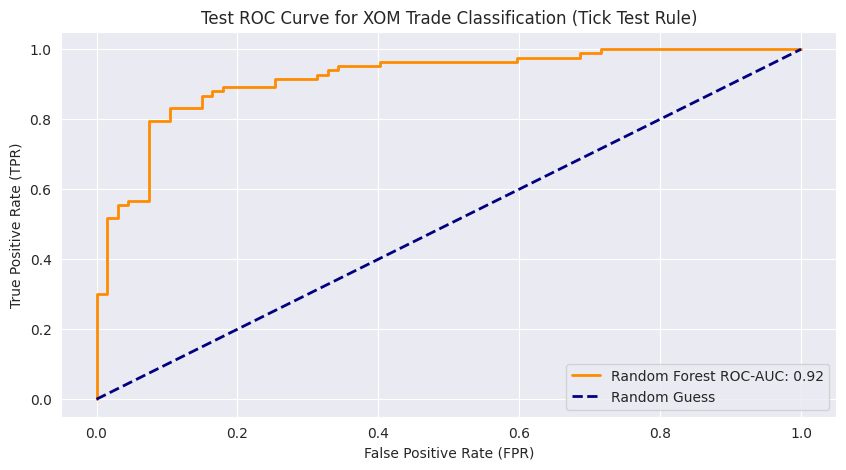

In [25]:
y_prob_test = grid_search.predict_proba(X_test)[:, 1]
fpr_test, tpr_test, thresholds = roc_curve(y_test, y_prob_test)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize = (10, 5))
sns.set_style("darkgrid")
plt.plot(fpr_test, tpr_test, color = "darkorange", lw = 2, label = "Random Forest ROC-AUC: {:.2f}".format(roc_auc_test))
plt.plot([0, 1], [0, 1], color = "navy", lw = 2, linestyle = "--", label = "Random Guess")
plt.title("Test ROC Curve for XOM Trade Classification (Tick Test Rule)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.show()

# Feature Importances

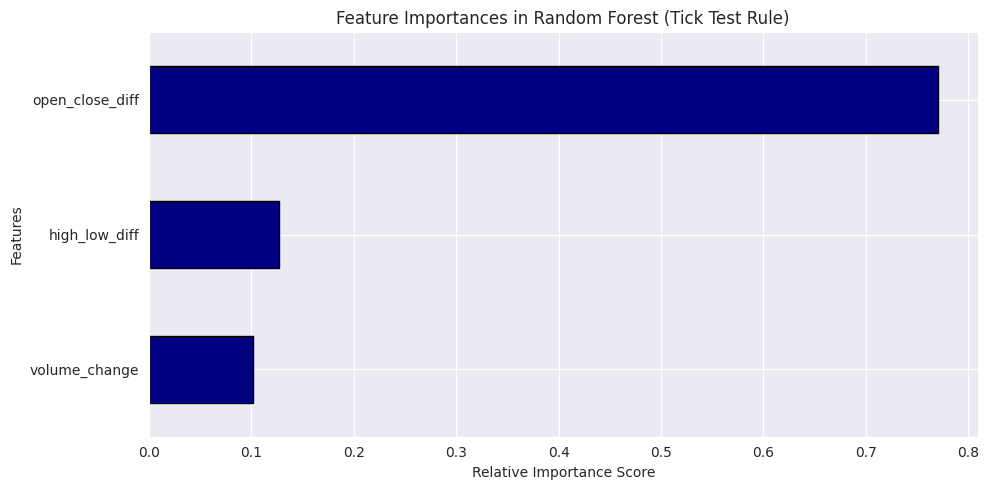

In [29]:
importances = grid_search.best_estimator_.feature_importances_

feature_names = X.columns

feat_importances = pd.Series(importances, index = feature_names)

feat_importances = feat_importances.sort_values(ascending = True)

plt.figure(figsize = (10, 5))
feat_importances.plot(kind = "barh", color = "navy", edgecolor = "black")
plt.title("Feature Importances in Random Forest (Tick Test Rule)")
plt.xlabel("Relative Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()